In [106]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

IMEI: 869487064492787

In [107]:
#01-Oct-2026 to 05-Oct-2026
raw_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Downloads\ein621_0110_0510.xlsx')
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9708 entries, 0 to 9707
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  9708 non-null   str  
 1   Message  9708 non-null   str  
 2   Status   9708 non-null   str  
dtypes: str(3)
memory usage: 227.7 KB


In [108]:
aux=pd.DataFrame()
aux=raw_data
aux['Headers']='NaN'

for i in range(0,aux.shape[0]):
    aux.iloc[i,3]=aux.iloc[i,2][0:8]

aux['Headers'].value_counts()

Headers
0x252513    9617
0x252514      87
0x252501       2
0x252511       2
Name: count, dtype: int64

In [109]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9708 entries, 0 to 9707
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  9708 non-null   str  
 1   Message  9708 non-null   str  
 2   Status   9708 non-null   str  
 3   Headers  9708 non-null   str  
dtypes: str(4)
memory usage: 303.5 KB


Odometer

In [110]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux['Odometer in meters']=0.0
odometer=[]
date=[]
raw=[]
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    odometer.append(int(unit_aux.iloc[i,2][96:104],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Odometer in meters']=odometer
unit_aux['Date']=date
unit_aux['Raw data']=raw

#print(unit_aux['Odometer in meters'])

unit=unit_aux.sort_values('Date',ascending=True)

print(unit.info())

<class 'pandas.DataFrame'>
Index: 9704 entries, 0 to 9707
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Created             9704 non-null   str  
 1   Message             9704 non-null   str  
 2   Status              9704 non-null   str  
 3   Headers             9704 non-null   str  
 4   Odometer in meters  9704 non-null   int64
 5   Date                9704 non-null   str  
 6   Raw data            9704 non-null   str  
dtypes: int64(1), str(6)
memory usage: 606.5 KB
None


261001000010 -> 0 -> 17256417.0 -> 0x25251300591CD60869487064492787003C38402D000000604E00000007000061000000FFFFFFFFFFFFFFFFFFFF00D501074FE19126100100001000E0C244DC3597C22B8EC7400000004303871423FFFFFF0000280000FFFFFF
261001000013 -> 1 -> 17256418.0 -> 0x25251300591CD70869487064492787003C38402D000000604E00000007000061000000FFFFFFFFFFFFFFFFFFFF00D501074FE2912610010000139AE9C244DB3597C22B8EC7400000000003871421FFFFFF0000280000FFFFFF
261001000035 -> 2 -> 17256443.0 -> 0x25251300591CD80869487064492787003C38402D000000594E00000007000061000000FFFFFFFFFFFFFFFFFFFF00D501074FFB912610010000356676C244DC3597C20690C7400020003403871419FFFFFF0000290000FFFFFF
261001000036 -> 3 -> 17256444.0 -> 0x25251300591CD90869487064492787003C38402D00000059CE00000007000061000000FFFFFFFFFFFFFFFFFFFF00D501074FFC912610010000363393C244DD3597C21590C7400000000003871414FFFFFF0000290000FFFFFF
261001000116 -> 4 -> 17256504.0 -> 0x25251300591CDA0869487064492787003C38402D000000564F00000007000061000000FFFFFFFFFFFFFFFFFFFF00D501075

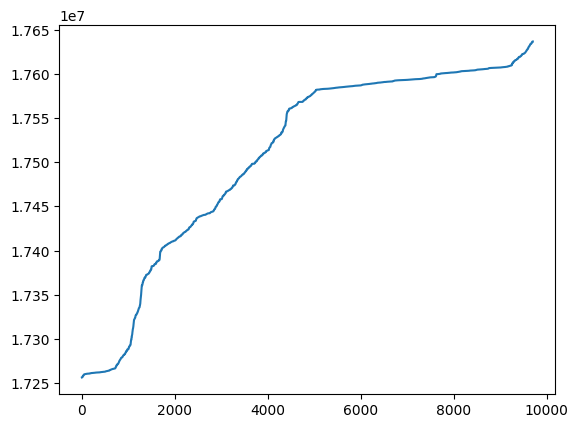

In [111]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,4]))
    x_axis.append(i)
    date.append(unit.iloc[i,5])
    raw_data_.append(unit.iloc[i,6])

#print("Delta odometer: ",y_axis[170]-y_axis[133],'meters')

for i in range(0,len(odometer)):
    print(date[i],'->',x_axis[i],'->',y_axis[i],'->',raw_data_[i])

#print(odometer[len(odometer)-1]-odometer[0])
plt.plot(x_axis,y_axis)

In [112]:
y_axis_sr=[]
x_axis_sr=[]
date_sr=[]
raw_data_sr=[]
speed_sr=[]
bottom_lim=12703240-300
upper_lim=12703240+300
unit.info()

for i in range(0,unit.shape[0]):
    #print(unit.iloc[i,4],'->',bottom_lim,'->',upper_lim)
    if unit.iloc[i,4]>bottom_lim and unit.iloc[i,4]<upper_lim:
        y_axis_sr.append(float(unit.iloc[i,4]))
        x_axis_sr.append(i)
        date_sr.append(unit.iloc[i,3])
        raw_data_sr.append(unit.iloc[i,2])
        speed_sr.append(int(unit.iloc[i,2][142:145]))  
        print(bottom_lim,'->',unit.iloc[i,4],'->',upper_lim,'->',unit.iloc[i,2][142:145])

report_highspeed_sr=pd.DataFrame()
report_highspeed_sr['Date']=date_sr
report_highspeed_sr['Raw data']=raw_data_sr
report_highspeed_sr['Speed']=speed_sr
report_highspeed_sr['odometer']=y_axis_sr

report_highspeed_sr.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\cea\ein621_hs_odometer.csv')

<class 'pandas.DataFrame'>
Index: 9704 entries, 0 to 9707
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Created             9704 non-null   str  
 1   Message             9704 non-null   str  
 2   Status              9704 non-null   str  
 3   Headers             9704 non-null   str  
 4   Odometer in meters  9704 non-null   int64
 5   Date                9704 non-null   str  
 6   Raw data            9704 non-null   str  
dtypes: int64(1), str(6)
memory usage: 606.5 KB


Speed

In [113]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
#unit_aux['Odometer in meters']=0.0
speed=[]
date=[]
raw=[]
unit_speed=pd.DataFrame()
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    try:
        lbs_ind=(bin(int(unit_aux.iloc[i,2][50:52],16) & 64))
        if lbs_ind=='0b1000000':
            speed.append(int(unit_aux.iloc[i,2][142:145]))  
            date.append(unit_aux.iloc[i,2][106:118])
            raw.append(unit_aux.iloc[i,2])
            #print(lbs_ind)
    except:
        pass 
    
unit_speed['Speed']=speed
unit_speed['Date']=date
unit_speed['Raw data']=raw

unit=unit_speed.sort_values('Date',ascending=True)

print(unit.info())

<class 'pandas.DataFrame'>
Index: 9704 entries, 0 to 9703
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Speed     9704 non-null   int64
 1   Date      9704 non-null   str  
 2   Raw data  9704 non-null   str  
dtypes: int64(1), str(2)
memory usage: 303.2 KB
None


26 261001064838 0x25251300591F1B0869487064492787003C38402D0000003AC700000007000020000000FFFFFFFFFFFFFFFFFFFF00D501076E0B652610010648386616C344FB3397C245FDC7400260007903801256FFFFFF0000230002FFFFFF
26 261001064838 0x25251300591F1A0869487064492787003C38402D0000003AC700000007000020000000FFFFFFFFFFFFFFFFFFFF00D501076E0B652610010648386616C344FB3397C245FDC7400260007903801256FFFFFF0000230002FFFFFF
65 261001064839 0x25251300591F1C0869487064492787003C38402D0000003AC700000007000020000000FFFFFFFFFFFFFFFFFFFF00D501076E1C652610010648399A79C244EE3397C25FFCC7400650007B03801256FFFFFF0000240002FFFFFF
32 261001142446 0x2525130059211C0869487064492787003C38402D000000565200000007000061000000FFFFFFFFFFFFFFFFFFFF00D50108313B89261001142446CDFCDC44764397C2980DC340032000A003871436FFFFFF0000250000FFFFFF
54 261001142622 0x2525130059211D0869487064492787003C38402D000000595200000007000061000000FFFFFFFFFFFFFFFFFFFF00D5010835DD8926100114262200D0DD44E64297C2EFB7C240054000A003871439FFFFFF0000230000FFFFFF
61 261001142634

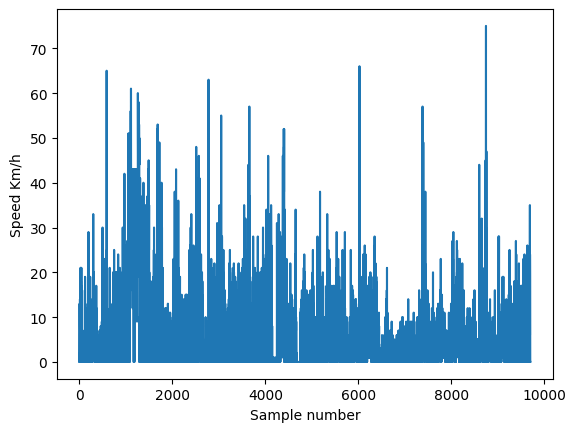

In [114]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]
date_report=[]
x_axis_report=[]
y_axis_report=[]
raw_data_report=[]
aux_i=0
report_higspeed=pd.DataFrame()

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,0]))
    x_axis.append(i)
    date.append(unit.iloc[i,1])
    raw_data_.append(unit.iloc[i,2])
    #print(raw_data_[i])
    
for i in range(0,len(speed)):
    if (y_axis[i]>60):
        date_report.append(date[i])
        x_axis_report.append(x_axis[i])
        y_axis_report.append(y_axis[i])
        raw_data_report.append(raw_data_[i])
        aux_i=i
        #print(y_axis[i])
        print(unit.iloc[aux_i-2,0],unit.iloc[aux_i-2,1],unit.iloc[aux_i-2,2])
        print(unit.iloc[aux_i-1,0],unit.iloc[aux_i-1,1],unit.iloc[aux_i-1,2])
        print(unit.iloc[aux_i,0],unit.iloc[aux_i,1],unit.iloc[aux_i,2])

report_higspeed['Date']=date_report
report_higspeed['Index']=x_axis_report
report_higspeed['Speed']=y_axis_report  
report_higspeed['Raw data']=raw_data_report

report_higspeed.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\cea\EIN621_highspeed.csv')
plt.ylabel("Speed Km/h")
plt.xlabel("Sample number")
plt.plot(x_axis,y_axis)

In [115]:
max(y_axis)

75.0

In [116]:
report_higspeed

,Date,Index,Speed,Raw data
0,261001064839,585,65.0,0x25251300591F1C0869487064492787003C38402D0000...
1,261001142634,1109,61.0,0x2525130059211E0869487064492787003C38402D0000...
2,261002080622,2778,63.0,0x252513005927930869487064492787003C38402D0000...
3,261003221103,6026,66.0,0x252513005934090869487064492787003C38402D0000...
4,261005034155,8747,70.0,0x25251300593EA90869487064492787003C38402D0000...
5,261005034200,8748,75.0,0x25251300593EAA0869487064492787003C38402D0000...


Satellites

In [117]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
satellite_number=[]
satellite_connection_indicator=[]
date=[]
raw=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    satellite_number.append(int(unit_aux.iloc[i,2][50:52],16) & 31)
    satellite_connection_indicator.append(int(unit_aux.iloc[i,2][50:52],16) & 128)
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Satellites']=satellite_number
unit_aux['Satellite_connection_indicator']=satellite_connection_indicator
unit_aux['Raw data']=raw
unit_aux['date']=date

unit=unit_aux.sort_values('date',ascending=True)
unit.info()

for i in range(0,unit.shape[0]):
    if unit.iloc[i,4]<1:
        num_events=num_events+1
        print(unit.iloc[i,0], '->',unit.iloc[i,4],'->',unit.iloc[i,5],'->',unit.iloc[i,6])

print("Eventos históricos: ",num_events)

<class 'pandas.DataFrame'>
Index: 9704 entries, 0 to 9707
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Created                         9704 non-null   str  
 1   Message                         9704 non-null   str  
 2   Status                          9704 non-null   str  
 3   Headers                         9704 non-null   str  
 4   Satellites                      9704 non-null   int64
 5   Satellite_connection_indicator  9704 non-null   int64
 6   Raw data                        9704 non-null   str  
 7   date                            9704 non-null   str  
dtypes: int64(2), str(6)
memory usage: 682.3 KB
Eventos históricos:  0


In/Outs

15      14                 13      12      11      10      09      08       07 06 05 04 03 02 01 00
Power   Ignition/Input0    Input1  Input2  Input3  Input4  Input5  Input0

15=0, Connected
15=1. Disconnected

In [118]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux.info()
aux_cad=[]
aux_date=[]
aux_raw_data=[]
aux_input_number=[]
in_outs=[]

#unit_aux.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\concatenated.csv')

for i in range(0,unit_aux.shape[0]):
    long_cad=len(unit_aux.iloc[i,2])
    if ((long_cad>48) & (long_cad<204)):
        aux_cad.append(unit_aux.iloc[i,2])   

for i in range(0,len(aux_cad)):
    aux_value=aux_cad[i][64:68]
    aux_date.append(aux_cad[i][106:118])
    aux_raw_data.append(aux_cad[i])
    in_outs.append(bin (int (aux_cad[i][64:68],16)))      

unit_=pd.DataFrame()
unit_['in and outs']=in_outs
unit_['date']=aux_date
unit_['raw data']=aux_raw_data

in_outs_df=unit_.sort_values('date',ascending=True)

#in_outs_df.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\in_outs.csv')

<class 'pandas.DataFrame'>
Index: 9704 entries, 0 to 9707
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  9704 non-null   str  
 1   Message  9704 non-null   str  
 2   Status   9704 non-null   str  
 3   Headers  9704 non-null   str  
dtypes: str(4)
memory usage: 379.1 KB


Power

In [119]:
ext_bat_13=raw_data[raw_data['Status'].str.contains('0x252513')]
ext_bat_14=raw_data[raw_data['Status'].str.contains('0x252514')]
ext_bat_vol=pd.concat([ext_bat_13,ext_bat_14])
ext_bat=[]
date_bat=[]
bat_df=pd.DataFrame()

ext_bat_vol.info()

for i in range(0,ext_bat_vol.shape[0]):
    val=(float(ext_bat_vol.iloc[i,2][154:158]))/100
    date_bat.append(ext_bat_vol.iloc[i,2][106:119])
    ext_bat.append(val)
#print(ext_bat)

for i in range(0,ext_bat_vol.shape[0]):
    if ext_bat[i]<3:
        bat_df['Date']=date_bat
        bat_df['int_bat']=ext_bat

print(bat_df)

<class 'pandas.DataFrame'>
Index: 9704 entries, 0 to 9707
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  9704 non-null   str  
 1   Message  9704 non-null   str  
 2   Status   9704 non-null   str  
 3   Headers  9704 non-null   str  
dtypes: str(4)
memory usage: 379.1 KB
Empty DataFrame
Columns: []
Index: []


Pánico

In [120]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux.info()
aux_cad=[]
aux_date=[]
aux_raw_data=[]
aux_input_number=[]

#unit_aux.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\concatenated.csv')

for i in range(0,unit_aux.shape[0]):
    long_cad=len(unit_aux.iloc[i,2])
    if ((long_cad>48) & (long_cad<204)):
        aux_cad.append(unit_aux.iloc[i,2])   

for i in range(0,len(aux_cad)):
    aux_value=aux_cad[i][64:68]
    aux_date.append(aux_cad[i][106:118])
    #aux_raw_data.append(aux_cad[i])
    if aux_value=='03':
        print(aux_value, ' -> ',aux_date[i])    

print("len aux_cad: ",len(aux_cad))

<class 'pandas.DataFrame'>
Index: 9704 entries, 0 to 9707
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  9704 non-null   str  
 1   Message  9704 non-null   str  
 2   Status   9704 non-null   str  
 3   Headers  9704 non-null   str  
dtypes: str(4)
memory usage: 379.1 KB
len aux_cad:  9704
